In [110]:
import pandas as pd
import numpy as np

In [111]:
df=pd.read_csv('IMDB Dataset.csv')

In [112]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [113]:
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [115]:
df.shape

(50000, 2)

In [116]:
df['sentiment'] = df['sentiment'].replace({'positive': 1, 'negative': 0})

C:\Users\USER\AppData\Local\Temp\ipykernel_9360\1176190499.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sentiment'] = df['sentiment'].replace({'positive': 1, 'negative': 0})


In [117]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [118]:
import re
clean=re.compile('<.*?>')
re.sub(clean, '', df.iloc[2].review)

'I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.This was the most I\'d laughed at one of Woody\'s comedies in years (dare I say a decade?). While I\'ve never been impressed with Scarlet Johanson, in this she managed to tone down her "sexy" image and jumped right into a average, but spirited young woman.This may not be the crown jewel of his career, but it was wittier than "Devil Wears Prada" and more interesting than "Superman" a great comedy to go see with friends.'

In [119]:
def clean_html(text):
    clean=re.compile('<.*?>')
    return re.sub(clean, '',text)

In [120]:
df['review']=df['review'].apply(clean_html)

In [121]:
def convert_lower(text):
    return text.lower()

In [122]:
df['review']=df['review'].apply(convert_lower)

In [123]:
def remove_special(text):
    x=''
    for i in text:
        if i.isalnum():
            x=x+i
        else:
            x=x+' '
    return x

In [124]:
df['review']=df['review'].apply(remove_special)

In [125]:
import nltk

In [126]:
from nltk.corpus import stopwords

In [127]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))  

def remove_stopwords(text):
    return [
        word for word in text.split()
        if word not in stop_words
    ]

df['review'] = df['review'].apply(remove_stopwords)


In [128]:
df

,review,sentiment
0,"[one, reviewers, mentioned, watching, 1, oz, e...",1
1,"[wonderful, little, production, filming, techn...",1
2,"[thought, wonderful, way, spend, time, hot, su...",1
3,"[basically, family, little, boy, jake, thinks,...",0
4,"[petter, mattei, love, time, money, visually, ...",1
...,...,...
49995,"[thought, movie, right, good, job, creative, o...",1
49996,"[bad, plot, bad, dialogue, bad, acting, idioti...",0
49997,"[catholic, taught, parochial, elementary, scho...",0
49998,"[going, disagree, previous, comment, side, mal...",0


In [129]:
df

,review,sentiment
0,"[one, reviewers, mentioned, watching, 1, oz, e...",1
1,"[wonderful, little, production, filming, techn...",1
2,"[thought, wonderful, way, spend, time, hot, su...",1
3,"[basically, family, little, boy, jake, thinks,...",0
4,"[petter, mattei, love, time, money, visually, ...",1
...,...,...
49995,"[thought, movie, right, good, job, creative, o...",1
49996,"[bad, plot, bad, dialogue, bad, acting, idioti...",0
49997,"[catholic, taught, parochial, elementary, scho...",0
49998,"[going, disagree, previous, comment, side, mal...",0


In [130]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [131]:
y=[]
def stem_words(text):
    for i in text:
        y.append(ps.stem(i))
    z=y[:]
    y.clear()
    return z

In [132]:
df['review']=df['review'].apply(stem_words)

In [133]:
def join_back(list_input):
    return  " ".join(list_input)

In [134]:
df['review']=df['review'].apply(join_back)

In [135]:
df

,review,sentiment
0,one review mention watch 1 oz episod hook righ...,1
1,wonder littl product film techniqu unassum old...,1
2,thought wonder way spend time hot summer weeke...,1
3,basic famili littl boy jake think zombi closet...,0
4,petter mattei love time money visual stun film...,1
...,...,...
49995,thought movi right good job creativ origin fir...,1
49996,bad plot bad dialogu bad act idiot direct anno...,0
49997,cathol taught parochi elementari school nun ta...,0
49998,go disagre previou comment side maltin one sec...,0


In [136]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=1000)

In [137]:
X=cv.fit_transform(df['review']).toarray()

In [138]:
X.shape

(50000, 1000)

In [139]:
y=df.iloc[:,-1].values

In [140]:
y

array([1, 1, 1, ..., 0, 0, 0], shape=(50000,))

In [141]:
y.shape

(50000,)

In [142]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [143]:
X_train.shape

(40000, 1000)

In [144]:
X_test.shape

(10000, 1000)

In [145]:
y_train.shape

(40000,)

In [146]:
y_test.shape

(10000,)

In [147]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

In [148]:
clf1=GaussianNB()
clf2=MultinomialNB()
clf3=BernoulliNB()

In [149]:
clf1.fit(X_train,y_train)
clf2.fit(X_train,y_train)
clf3.fit(X_train,y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [150]:
y_pred1=clf1.predict(X_test)
y_pred2=clf2.predict(X_test)
y_pred3=clf3.predict(X_test)

In [151]:
from sklearn.metrics import accuracy_score


In [152]:
print("Gaussian: ",accuracy_score(y_test,y_pred1))
print("Multinomial: ",accuracy_score(y_test,y_pred2))
print("Bernoulli: ",accuracy_score(y_test,y_pred3))

Gaussian:  0.7979
Multinomial:  0.8393
Bernoulli:  0.842


In [153]:
from sklearn.metrics import classification_report

print("Gaussian:\n", classification_report(y_test, y_pred1))
print("Multinomial:\n", classification_report(y_test, y_pred2))
print("Bernoulli:\n", classification_report(y_test, y_pred3))


Gaussian:
               precision    recall  f1-score   support

           0       0.77      0.84      0.81      5013
           1       0.83      0.75      0.79      4987

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000

Multinomial:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84      5013
           1       0.83      0.85      0.84      4987

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000

Bernoulli:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84      5013
           1       0.83      0.87      0.85      4987

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84    

In [154]:
from sklearn.metrics import confusion_matrix

print("Gaussian:\n", confusion_matrix(y_test, y_pred1))
print("Multinomial:\n", confusion_matrix(y_test, y_pred2))
print("Bernoulli:\n", confusion_matrix(y_test, y_pred3))


Gaussian:
 [[4231  782]
 [1239 3748]]
Multinomial:
 [[4166  847]
 [ 760 4227]]
Bernoulli:
 [[4098  915]
 [ 665 4322]]


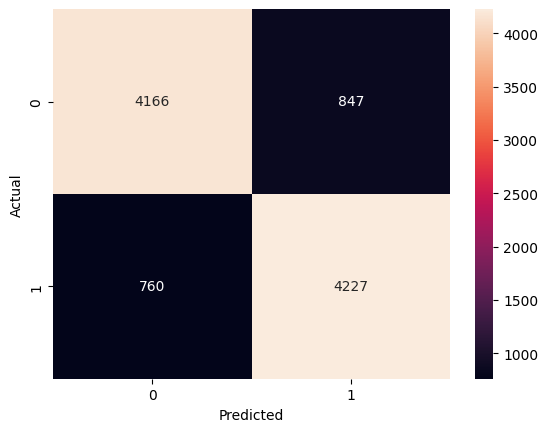

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred2)  # choose model

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
